In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/zerotrace11/tech-company-dataset/tech_company_employee_data_1000.csv
/kaggle/input/datasets/lovishbansal123/titanic-dataset/Titanic-Dataset.csv
/kaggle/input/datasets/sagnikpatra/uci-adult-census-data-dataset/adult_train.csv
/kaggle/input/datasets/sagnikpatra/uci-adult-census-data-dataset/adult_test.csv
/kaggle/input/datasets/shree1992/housedata/output.csv
/kaggle/input/datasets/shree1992/housedata/data.csv
/kaggle/input/datasets/shree1992/housedata/data.dat
/kaggle/input/datasets/iammustafatz/diabetes-prediction-dataset/diabetes_prediction_dataset.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.impute import SimpleImputer

In [3]:
uci = pd.read_csv('/kaggle/input/datasets/sagnikpatra/uci-adult-census-data-dataset/adult_train.csv')
diabetes = pd.read_csv('/kaggle/input/datasets/iammustafatz/diabetes-prediction-dataset/diabetes_prediction_dataset.csv')
titanic = pd.read_csv('/kaggle/input/datasets/lovishbansal123/titanic-dataset/Titanic-Dataset.csv')
house = pd.read_csv('/kaggle/input/datasets/shree1992/housedata/data.csv')

# impute missing values of occupation column of uci dataset

In [4]:
# Initial null percentage
null_rate = (uci['Occupation'].isnull().mean() * 100).astype(np.float16)
print(f"Percentage of null values in Occupation column is {null_rate:.2f}%")

# Imputation
imputer = SimpleImputer(strategy='most_frequent')
imputed = imputer.fit_transform(uci[['Occupation']])
uci[['Occupation']] = pd.DataFrame(imputed)

print("Imputation completed")

# After imputation, check null percentage
null_rate = uci['Occupation'].isnull().mean() * 100
print(f"After imputation, percentage of null values in Occupation column is {null_rate:.2f}%")


Percentage of null values in Occupation column is 5.66%
Imputation completed
After imputation, percentage of null values in Occupation column is 0.00%


# Outliers

# 1. find and mitigate(trimming and capping both) outliers on age column of diabetes dataset

This data being right skewed, we can not use emperical rule. So, we shall use Tukey's Fences instead


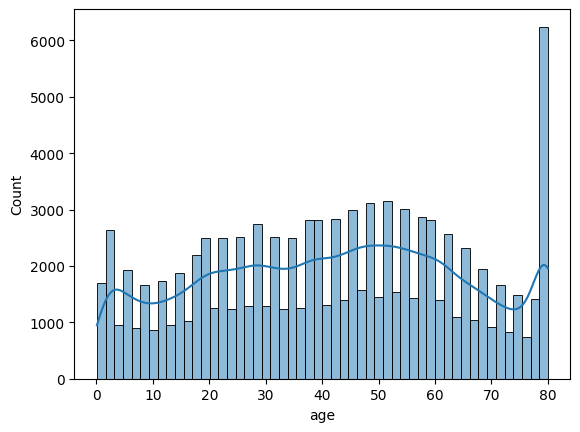

In [5]:
sns.histplot(data=diabetes[['age']], x = 'age', kde=True)
print("This data being right skewed, we can not use emperical rule. So, we shall use Tukey's Fences instead")

<Axes: >

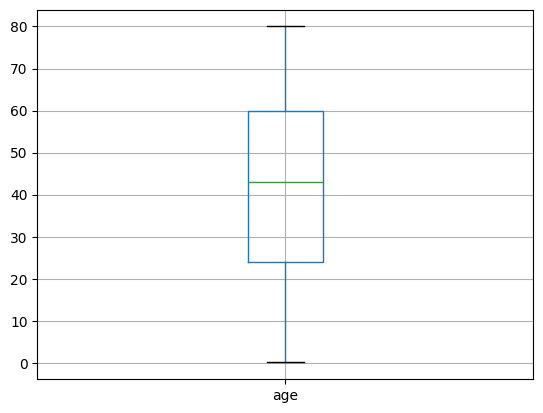

In [6]:
diabetes[['age']].boxplot()

In [7]:
# Use single brackets so it treats 'age' as a Series
q1 = diabetes['age'].quantile(0.25)
q3 = diabetes['age'].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Now this comparison works seamlessly
outlier_percentage = ((diabetes['age'] < lower_bound) | (diabetes['age'] > upper_bound)).mean() * 100
print(f"Based on Tukey's Fences method, we find {outlier_percentage}% of data in age column to be outliers")

Based on Tukey's Fences method, we find 0.0% of data in age column to be outliers


# 2. find and mitigate(trimming and capping both) outliers on price column of house dataset

This data being right skewed, we can not use emperical rule. So, we shall use Tukey's Fences instead


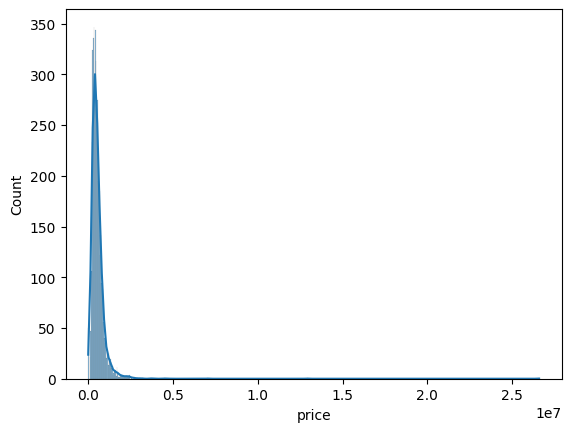

In [8]:
sns.histplot(data=house[['price']], x = 'price', kde=True)
print("This data being right skewed, we can not use emperical rule. So, we shall use Tukey's Fences instead")

<Axes: >

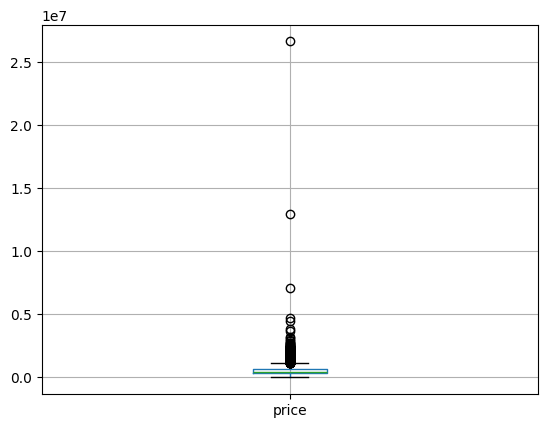

In [9]:
house[['price']].boxplot()

In [10]:
q1 = house['price'].quantile(0.25)
q3 = house['price'].quantile(0.75)

iqr = q3 - q1

lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr
outlier_percentage = ((house['price'] < lower_limit) | (house['price'] > upper_limit)).mean() * 100
print(f"Based on Tukey's Fences method, we find {outlier_percentage}% of data in price column to be outliers")

Based on Tukey's Fences method, we find 5.217391304347826% of data in price column to be outliers


In [11]:
house[(house['price'] < lower_limit) | (house['price'] > upper_limit)]

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
1,2014-05-02 00:00:00,2.384000e+06,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
11,2014-05-02 00:00:00,1.400000e+06,4.0,2.50,2920,4000,1.5,0,0,5,1910,1010,1909,1988,3838-4098 44th Ave NE,Seattle,WA 98105,USA
14,2014-05-02 00:00:00,1.200000e+06,5.0,2.75,2910,9480,1.5,0,0,3,2910,0,1939,1969,3534 46th Ave NE,Seattle,WA 98105,USA
99,2014-05-05 00:00:00,1.395000e+06,5.0,3.50,4010,8510,2.0,0,1,5,2850,1160,1971,0,3930 NE Belvoir Pl,Seattle,WA 98105,USA
122,2014-05-05 00:00:00,2.280000e+06,7.0,8.00,13540,307752,3.0,0,4,3,9410,4130,1999,0,26408 NE 70th St,Redmond,WA 98053,USA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4348,2014-05-05 00:00:00,2.199900e+06,4.0,1.50,1120,5427,1.0,0,0,3,1120,0,1969,2014,19009-19021 SE 266th St,Covington,WA 98042,USA
4350,2014-07-03 00:00:00,2.659000e+07,3.0,2.00,1180,7793,1.0,0,0,4,1180,0,1992,0,12005 SE 219th Ct,Kent,WA 98031,USA
4465,2014-06-05 00:00:00,2.560498e+06,3.0,2.50,1710,1664,2.0,0,0,5,1300,410,2003,0,2826 21st Ave W,Seattle,WA 98199,USA
4467,2014-06-06 00:00:00,1.337044e+06,4.0,3.50,4280,9583,2.0,0,0,3,4280,0,2005,0,1415 108th Ave SE,Bellevue,WA 98004,USA
